# Building a Multi-Step Pipeline

Chain `Data`s so downstream loaders depend on upstream ones,
forming a DAG that `pygeodata` manages automatically.
If an upstream loader's code or parameters change, all downstream
caches are automatically invalidated.

In [1]:
import os
os.chdir("../../..")

In [2]:
from dataclasses import dataclass
from pathlib import Path
import numpy as np

from pygeodata import Data, SpatialSpec, load, set_config
from pygeodata.visualisations import plot_compact_execution_graph, plot_class_dependency_graph
from pyproj import CRS
from affine import Affine
import json

set_config(path_data_processed=Path("./data/processed"))

spec = SpatialSpec(
    crs=CRS.from_epsg(4326),
    transform=Affine(0.25, 0, -180, 0, -0.25, 90),
    shape=(720, 1440),
)

## Defining loaders for NDVI

These loaders do not store anything, they just overwrite load to represent the parameters. In this example we calculate NDVI values based on red and near infrared bands. Red and NIR are defined as follows:

In [3]:
# @dataclass
# class Red(Data):
#     year: int

#     def _process(self, spec) -> None:
#         return

#     def load(self, spec):
#         return 0.05

#     driver = RioXArrayDriver()


# @dataclass
# class NIR(Data):
#     year: int

#     def _process(self, spec) -> None:
#         return

#     def load(self, spec):
#         return 0.5

#     driver = RioXArrayDriver()

NDVI can then ben defined in two ways. One by calling the Red and NIR objects in it's body, the other by injecting these objects as parameters. The latter is conceptually more powerful, but can be overkill in simple chains.

In [4]:
# @dataclass
# class NDVI(Data):
#     year: int

#     def _process(self, spec) -> None:
#         return

#     def load(self, spec):
#         red = load(Red(year=self.year), spec)
#         nir = load(NIR(year=self.year), spec)
#         return (nir - red) / (nir + red)

#     driver = RioXArrayDriver()

# @dataclass
# class NDVIInjection(Data):
#     red: Red
#     nir: NIR

#     def _process(self, spec) -> None:
#         return

#     def load(self, spec):
#         red = load(self.red, spec)
#         nir = load(self.nir, spec)
#         return (nir - red) / (nir + red)

#     driver = RioXArrayDriver()

In [5]:
from utils.docs_loaders import NDVI, Red, NIR, NDVIInjection

ndvi = NDVI(2020)

red = Red(2020)
nir = NIR(2020)
ndvi_2 = NDVIInjection(red=red, nir=nir)

## Inspecting loaders

Both execution and dependencies can be visualized with helper functions. Here you see the difference between the two conceptual approaches.

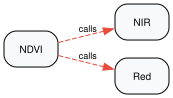

In [19]:
plot_class_dependency_graph(ndvi)

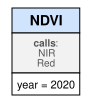

In [20]:
plot_compact_execution_graph(ndvi)

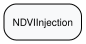

In [21]:
plot_class_dependency_graph(ndvi_2)

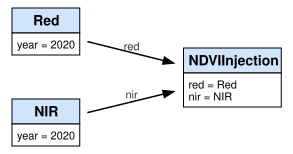

In [22]:
plot_compact_execution_graph(ndvi_2)

The resulting values are obviously equal

In [23]:
result = load(ndvi, spec)
result_2 = load(ndvi_2, spec)
print(result, result_2)

0.8181818181818181 0.8181818181818181


Inspect the hash chains

In [24]:
print(json.dumps(ndvi.get_dependency_tree(), indent=3))

{
   "class_name": "NDVI",
   "source_hash": "6fb2fb75759595b09072763633c4ea5a0c24fdd5422f74e136ff95ba057687d9",
   "call_dependencies": {
      "NIR": {
         "class_name": "NIR",
         "source_hash": "1aa3d0a71702ccadbc2884c23a4940a45b8196957e19bfdaa19b93f813876bc6",
         "call_dependencies": {},
         "inheritance_dependencies": {}
      },
      "Red": {
         "class_name": "Red",
         "source_hash": "39788caa2cc1a44319c6b7cdd5a28ab067031e70acdfd80d4c1652ca6dcabd5f",
         "call_dependencies": {},
         "inheritance_dependencies": {}
      }
   },
   "inheritance_dependencies": {}
}


In [25]:
print(json.dumps(ndvi_2.get_dependency_tree(), indent=3))

{
   "class_name": "NDVIInjection",
   "source_hash": "fbdb6f8f7c925979b75e84b40fa2d80db8065351556beb74ceeb93ef18163d2b",
   "call_dependencies": {},
   "inheritance_dependencies": {}
}
